# Credit Rating Prediction
## Model Development and Model Evaluation

---
## 0. Setup

Execute the full starter template to inherit all preprocessing variables, then import additional libraries needed for modeling.

Dataset shape: (2029, 31)

Columns: ['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector', 'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'enterpriseValueMultiple', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio', 'payablesTurnover']

First few rows:
<class 'pandas.DataFrame'>
RangeIndex: 2029 entries, 0 to 2028
Data columns (total 31 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Rating                              2029 non-null   str    
 1   Name                                2029 n

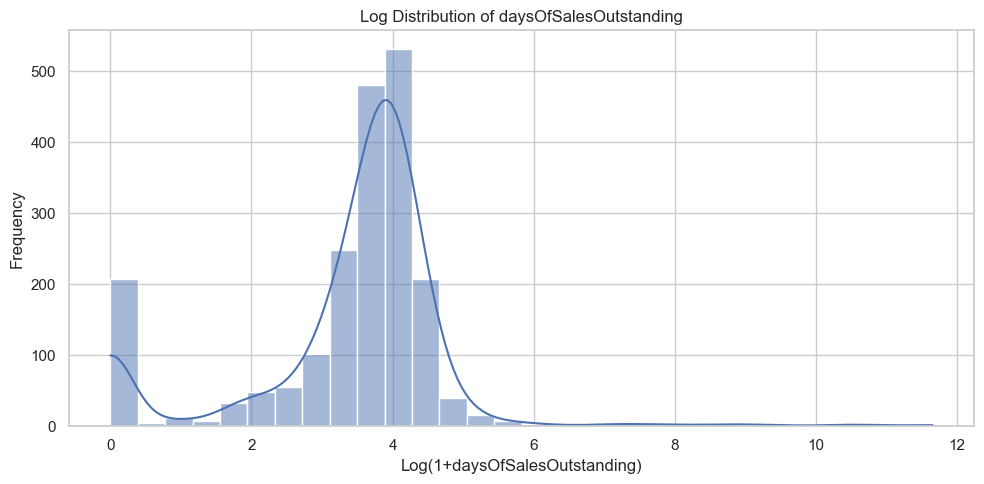

Variabili eliminate:  ['cashRatio', 'daysOfSalesOutstanding', 'pretaxProfitMargin', 'operatingProfitMargin', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'cashPerShare', 'companyEquityMultiplier', 'ebitPerRevenue', 'operatingCashFlowPerShare', 'operatingCashFlowSalesRatio']

Colonne rimaste:  ['currentRatio', 'quickRatio', 'netProfitMargin', 'grossProfitMargin', 'returnOnAssets', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'enterpriseValueMultiple', 'payablesTurnover']


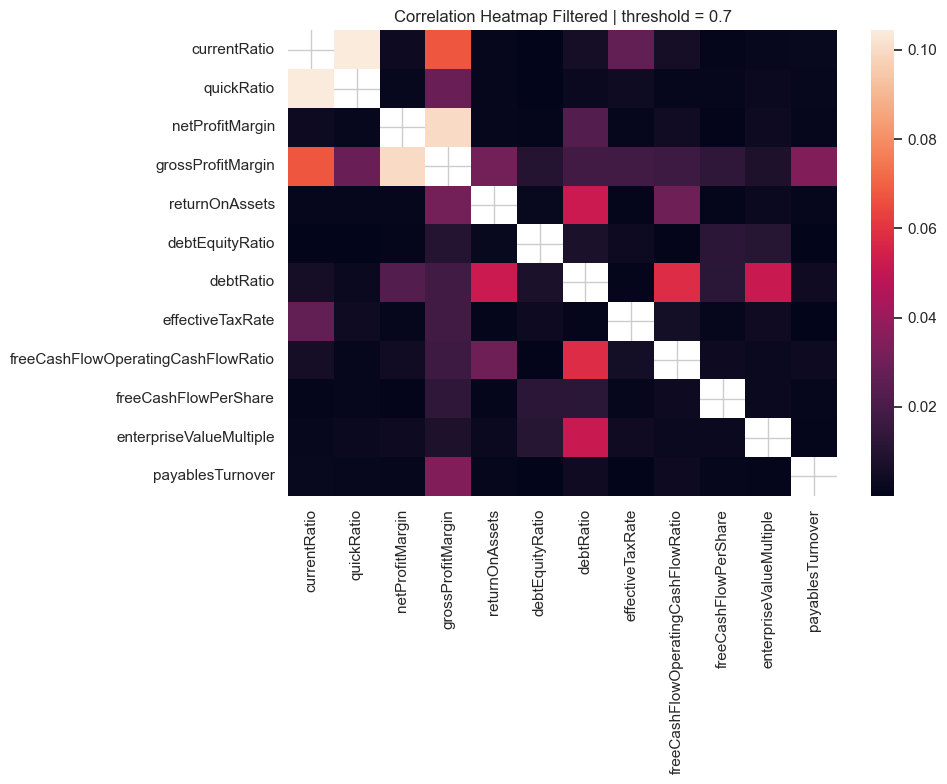

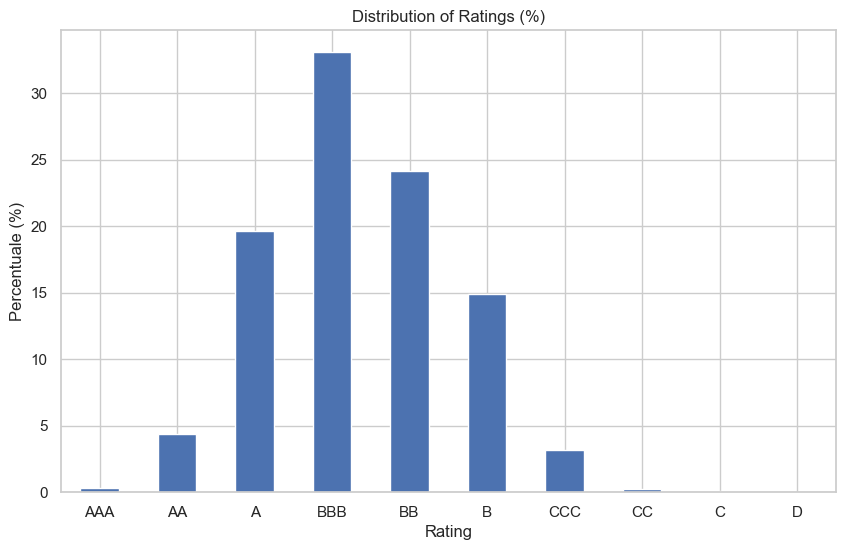

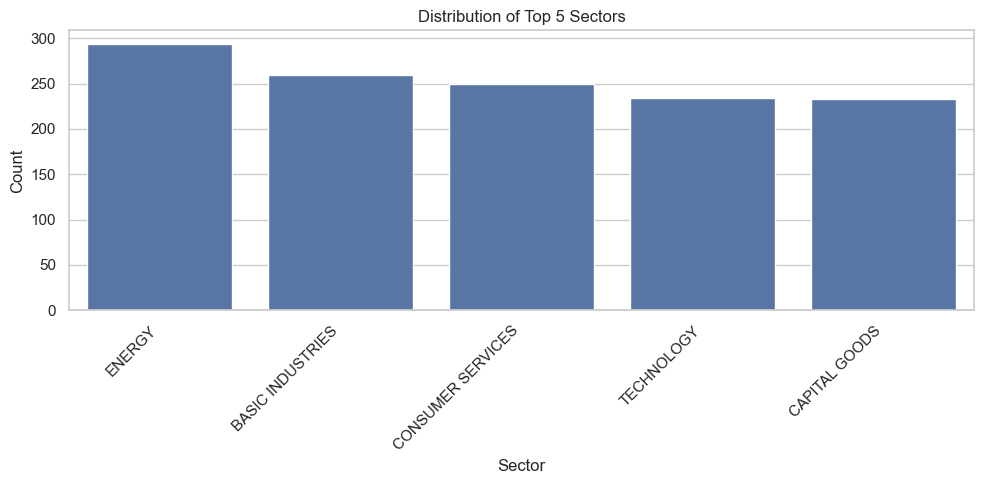

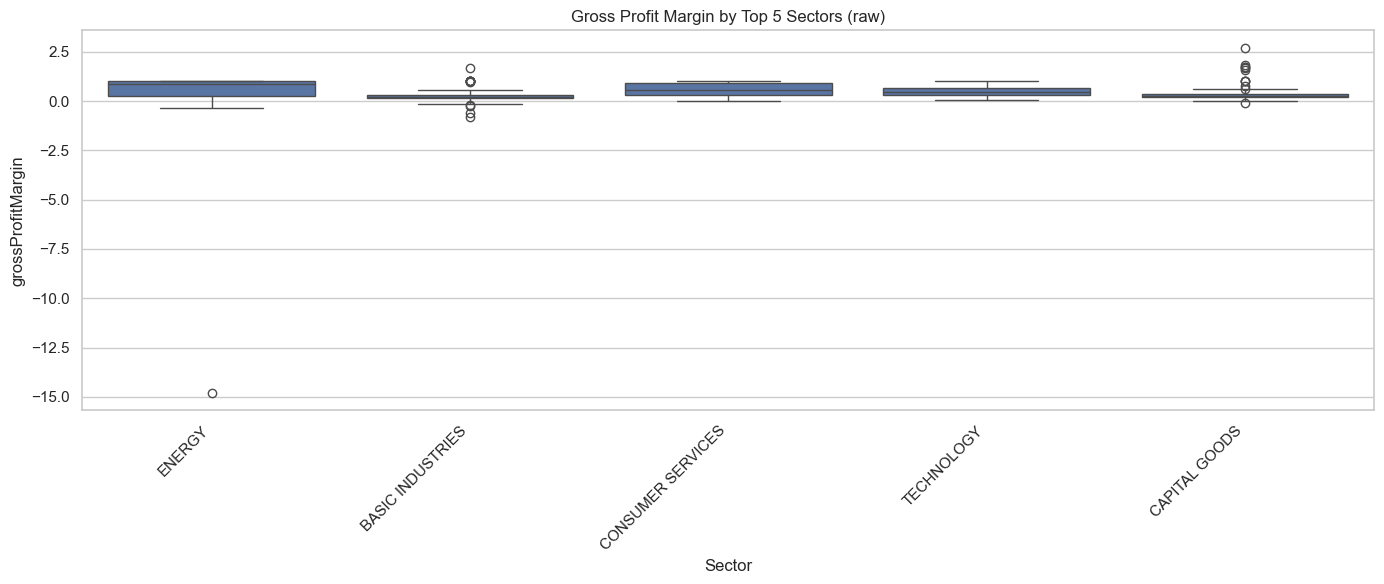

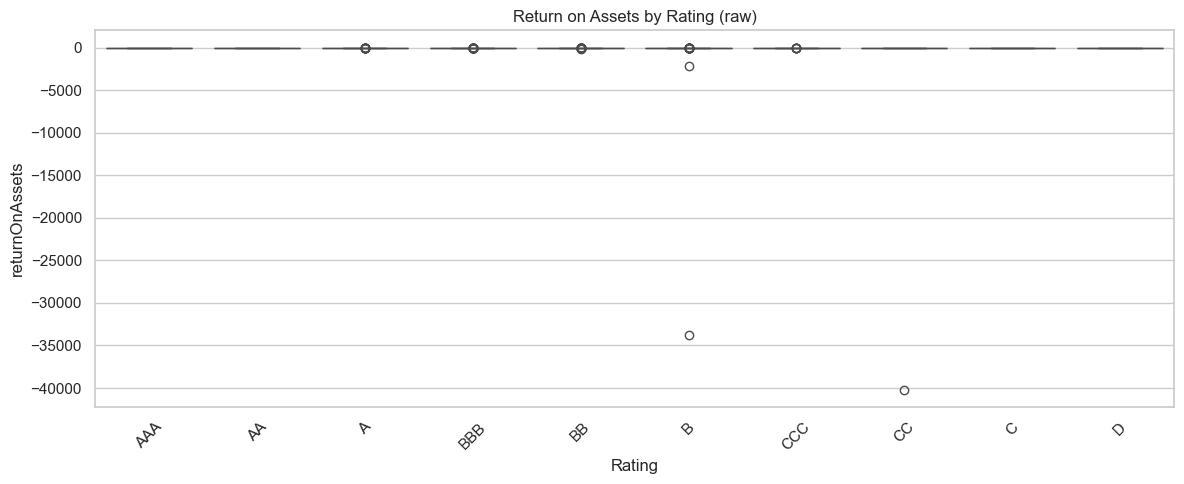

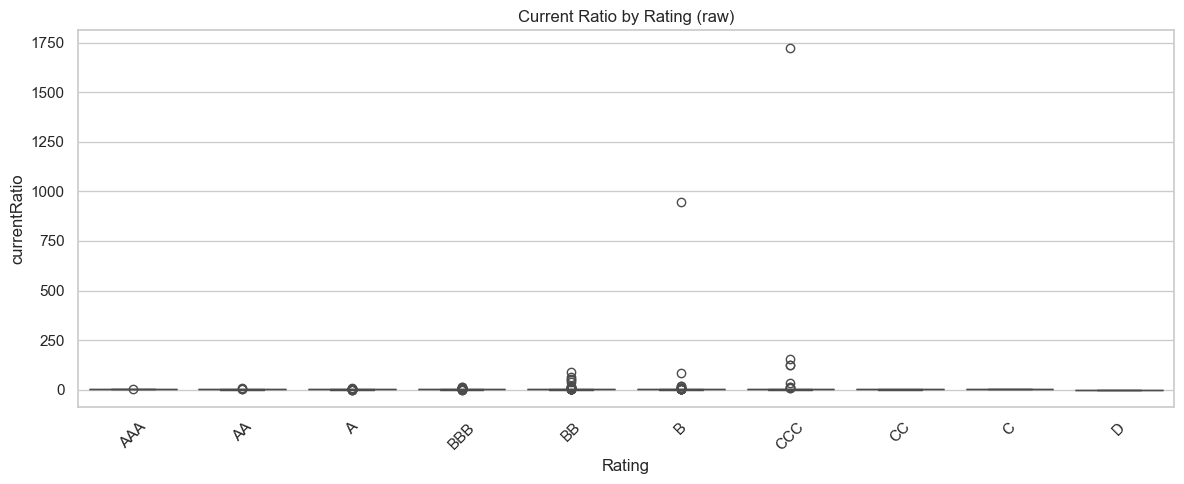

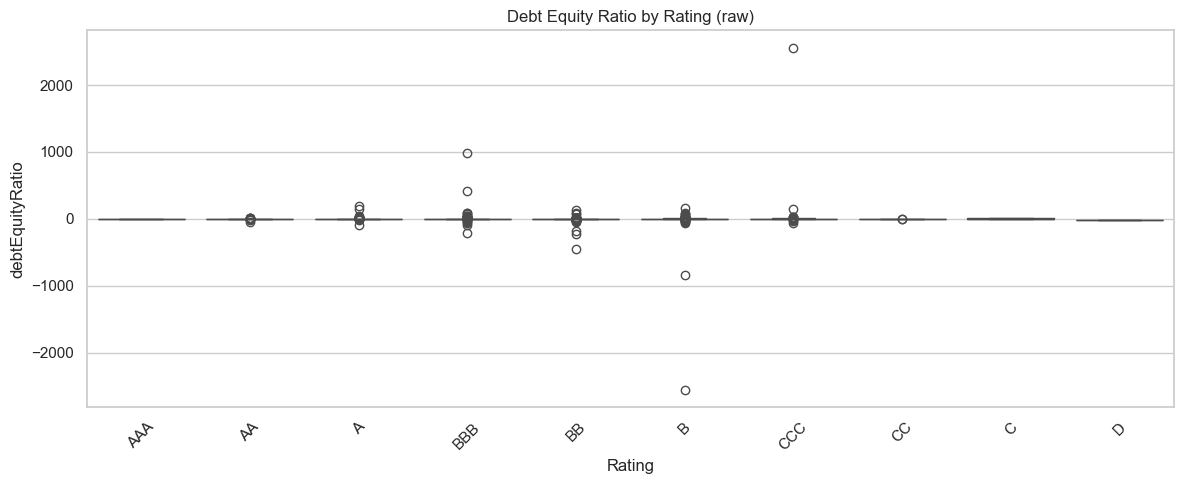

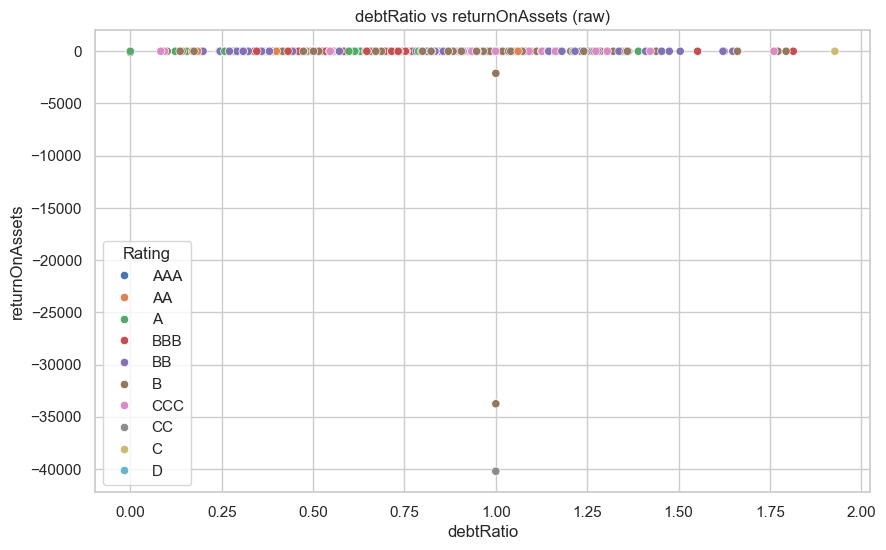

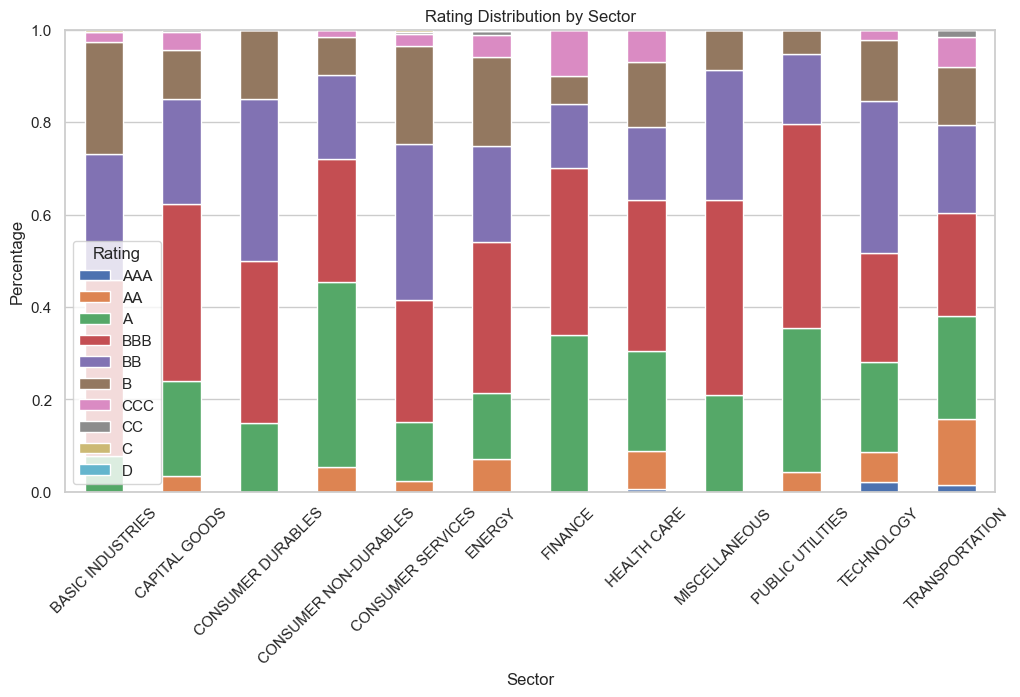

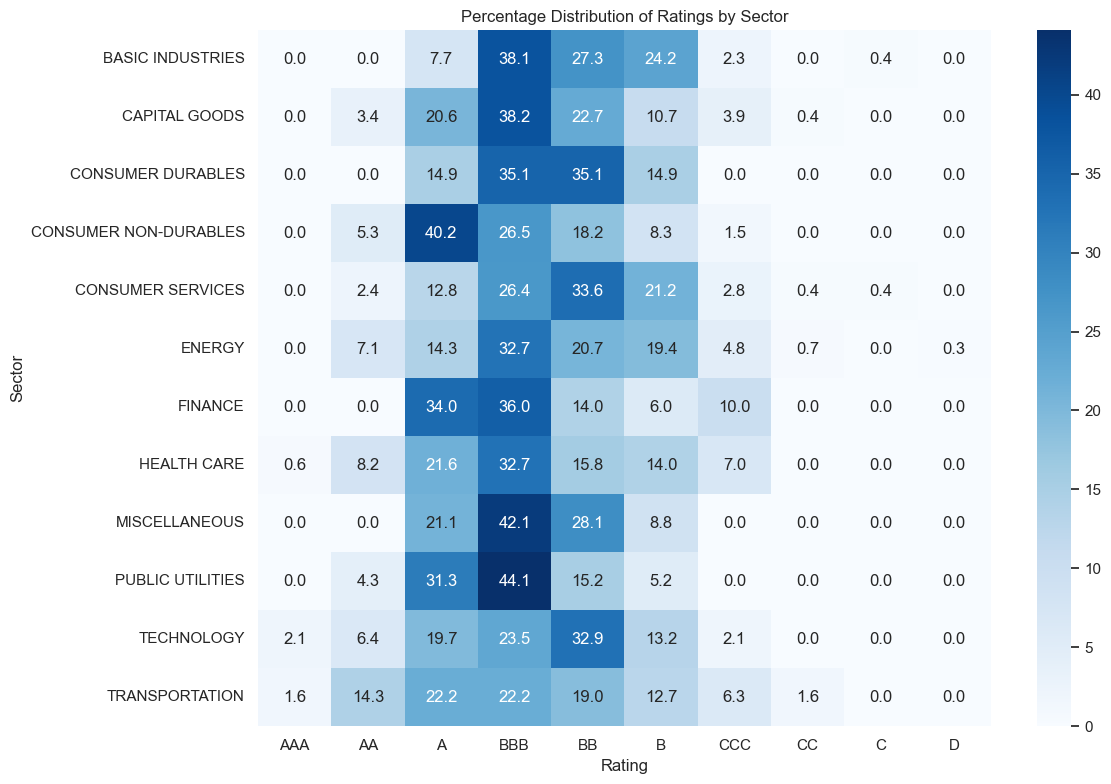

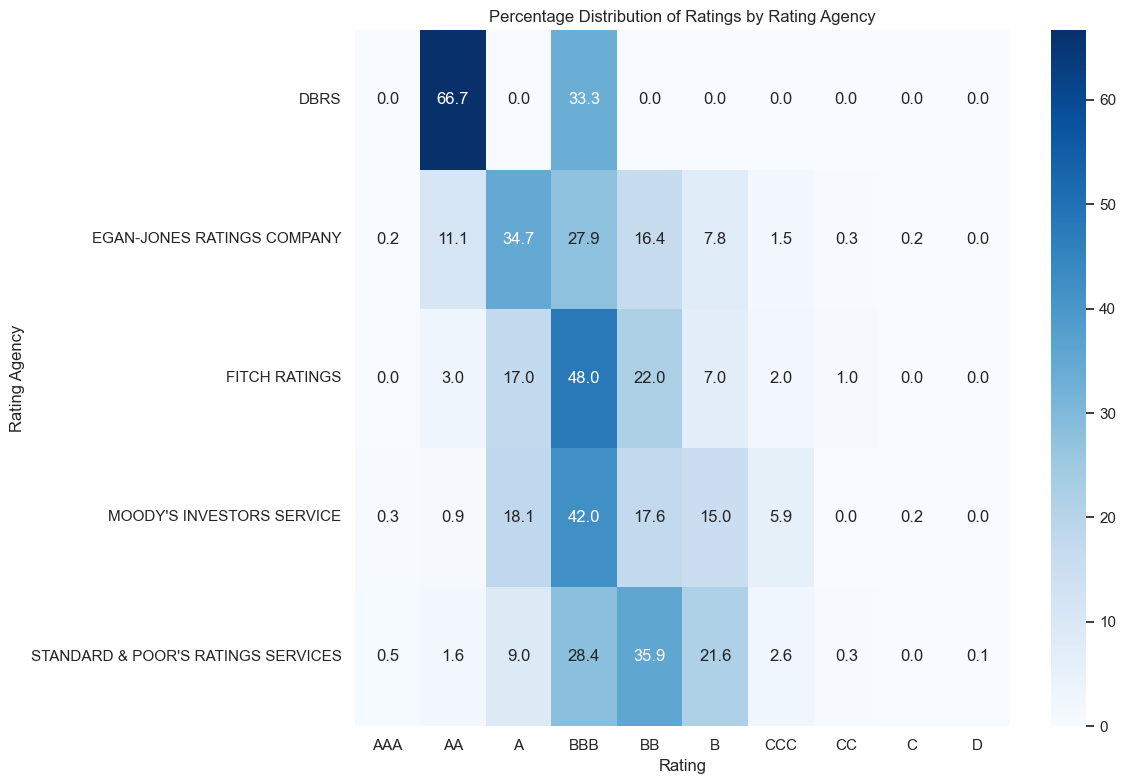

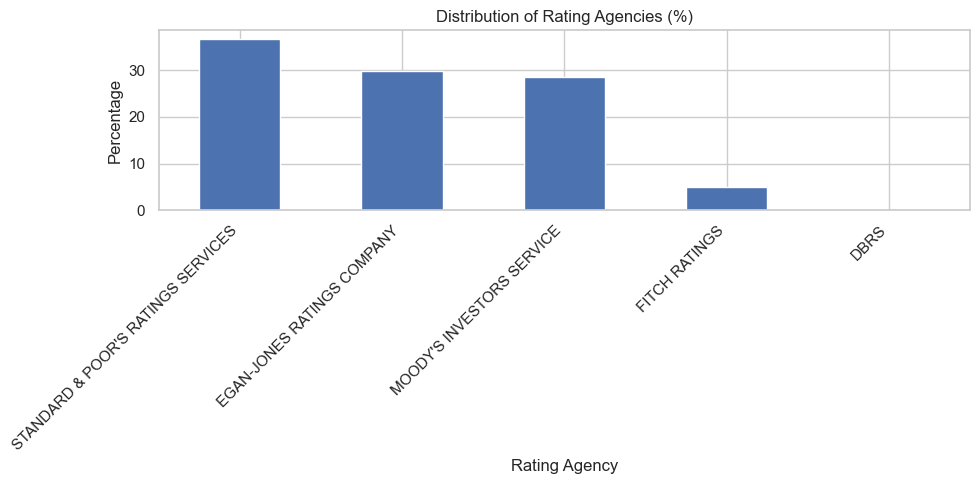

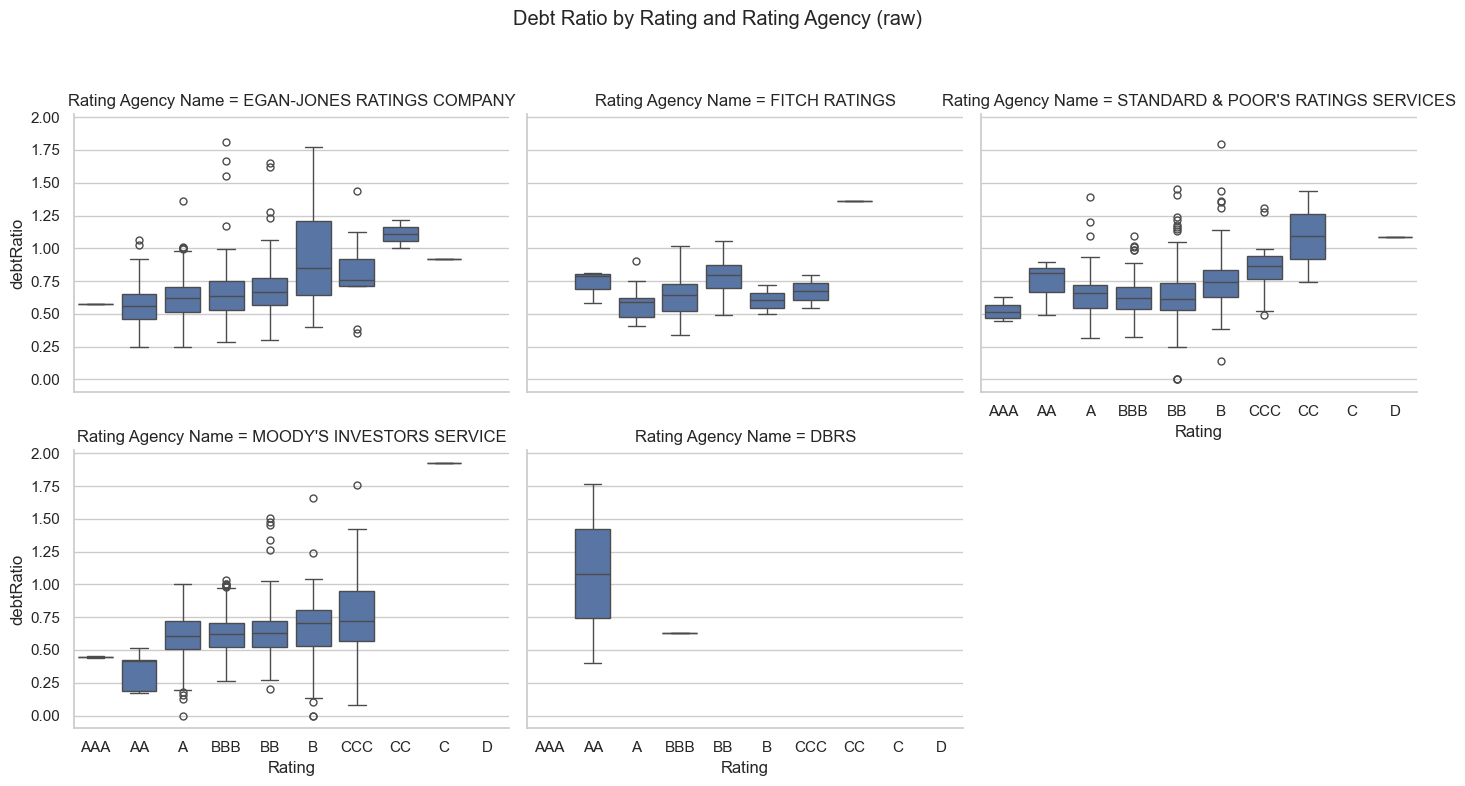

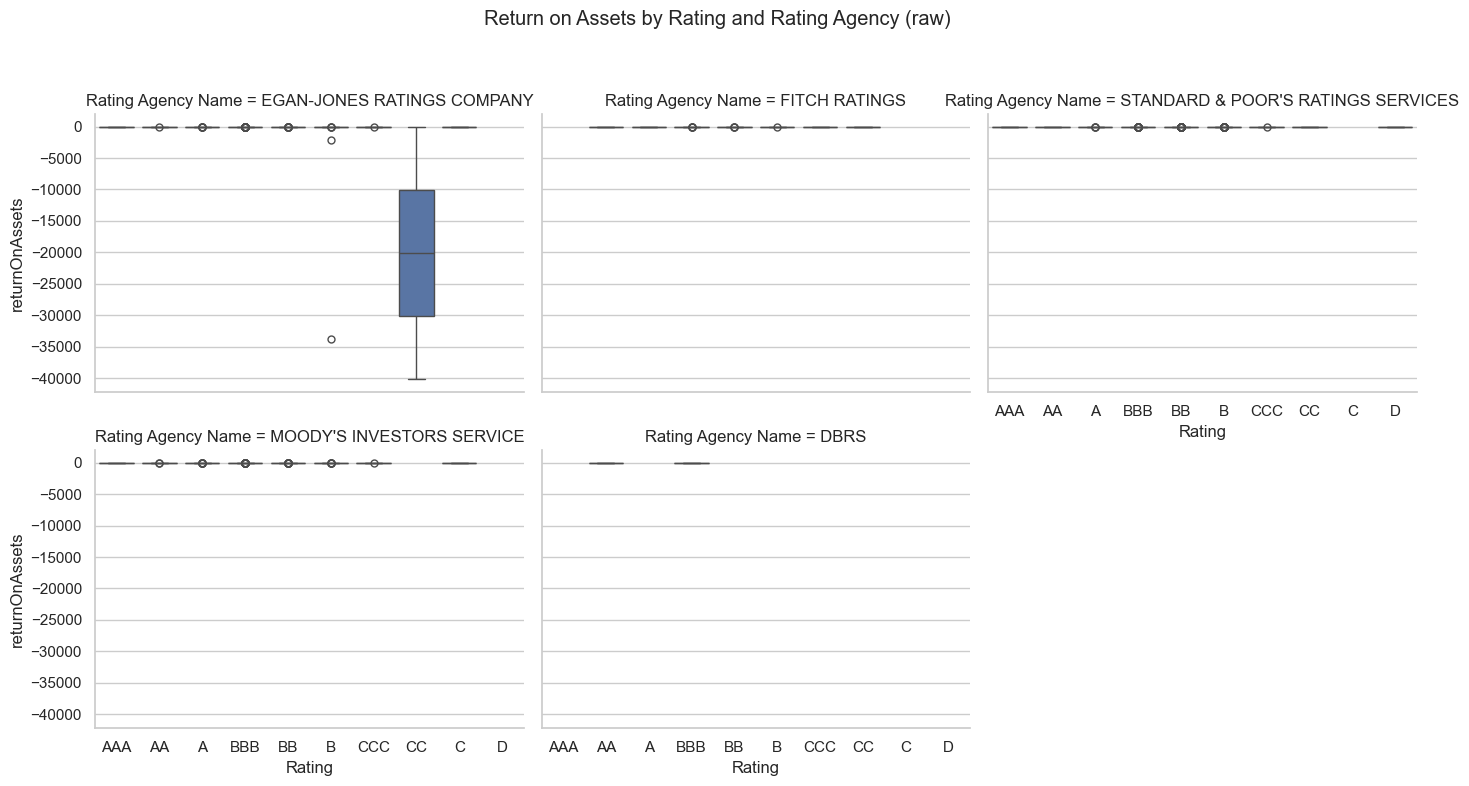

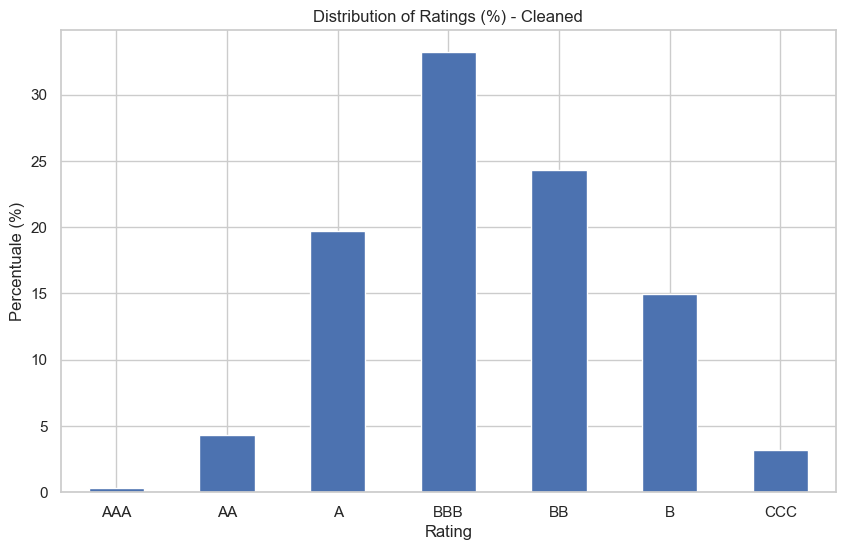

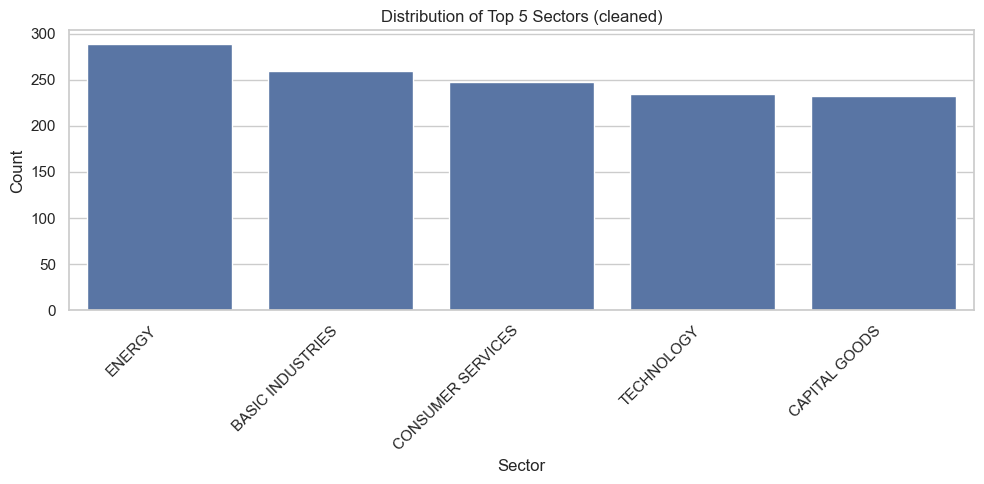

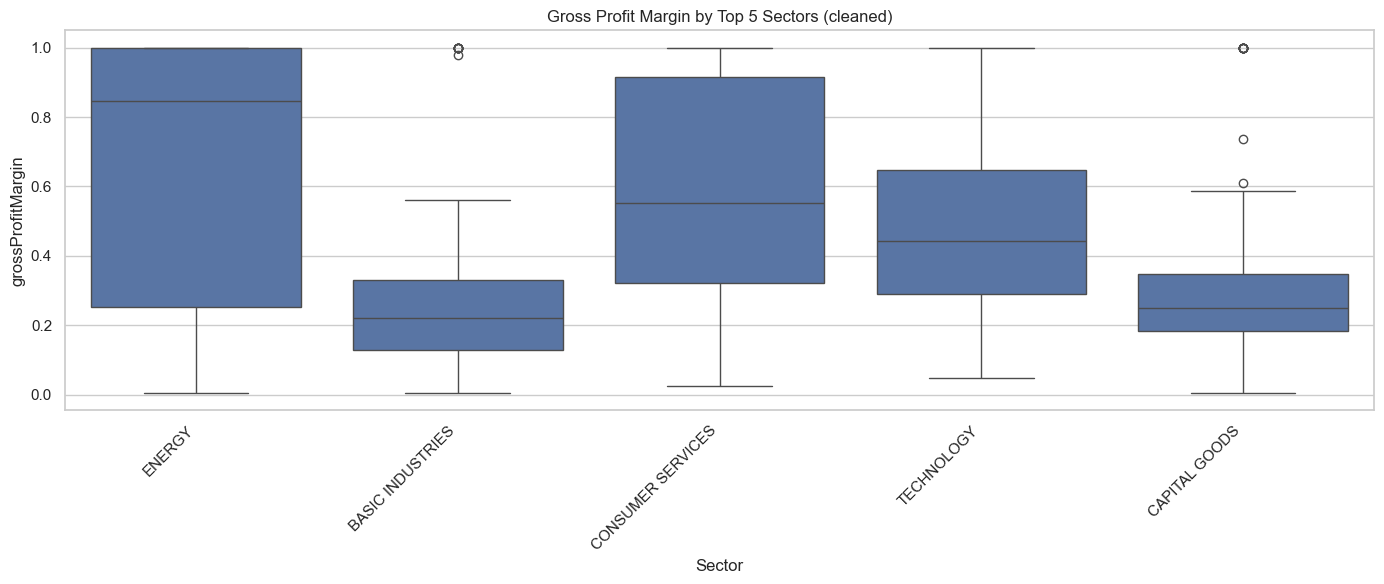

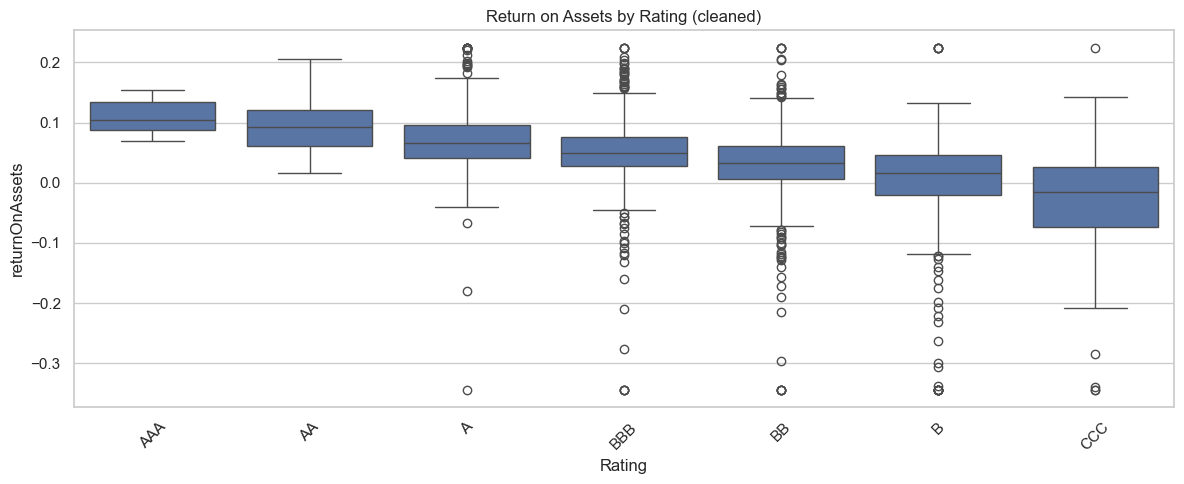

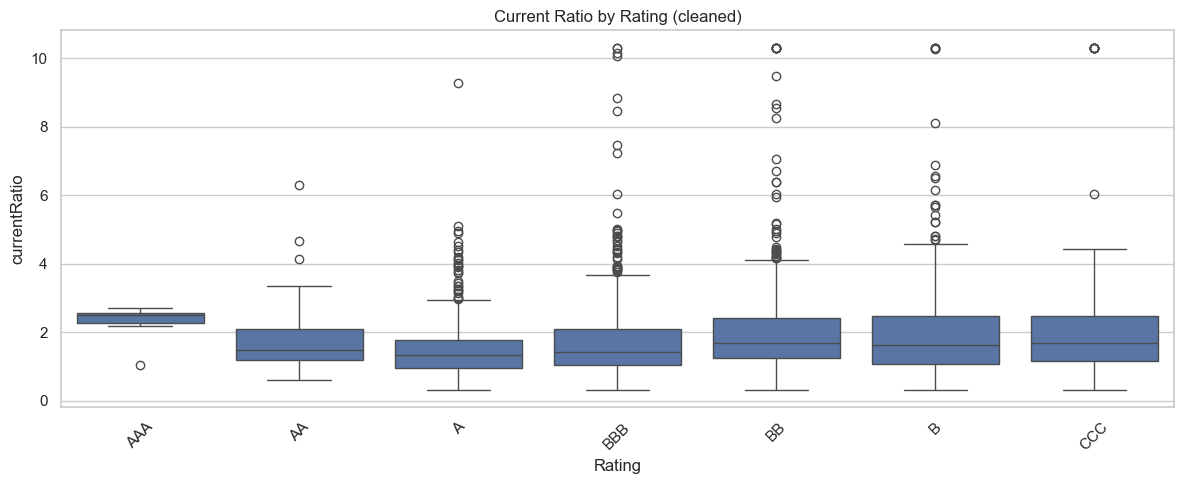

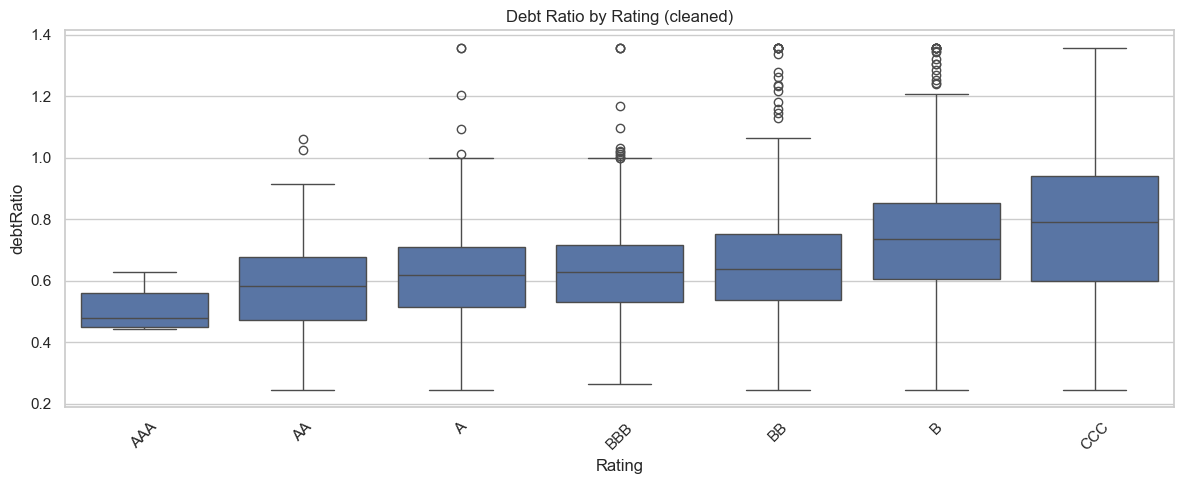

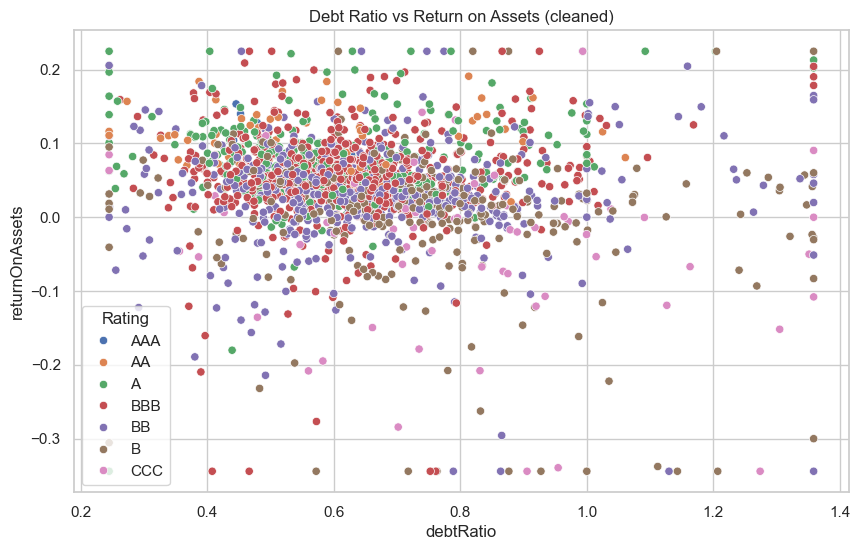

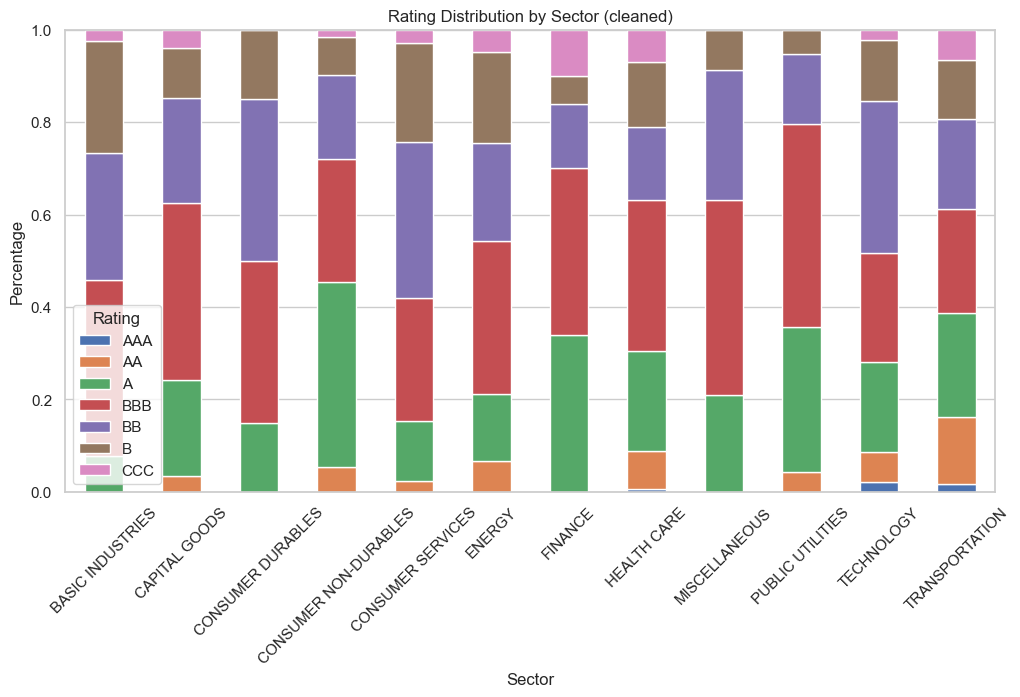

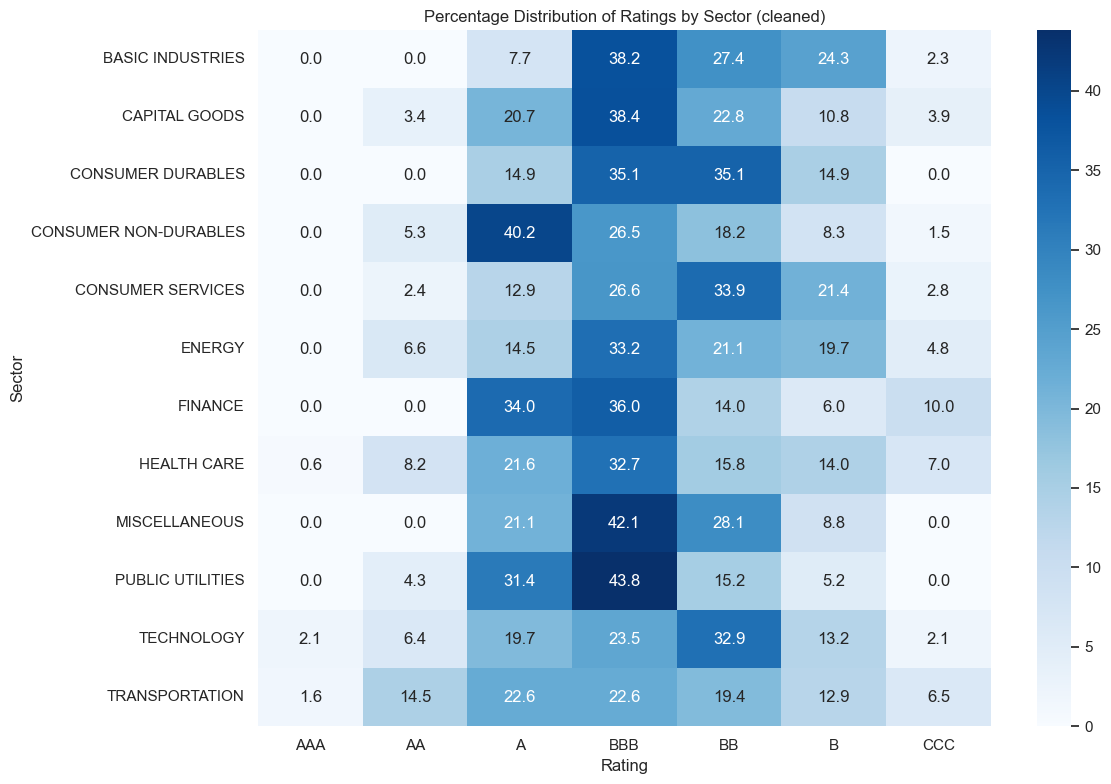

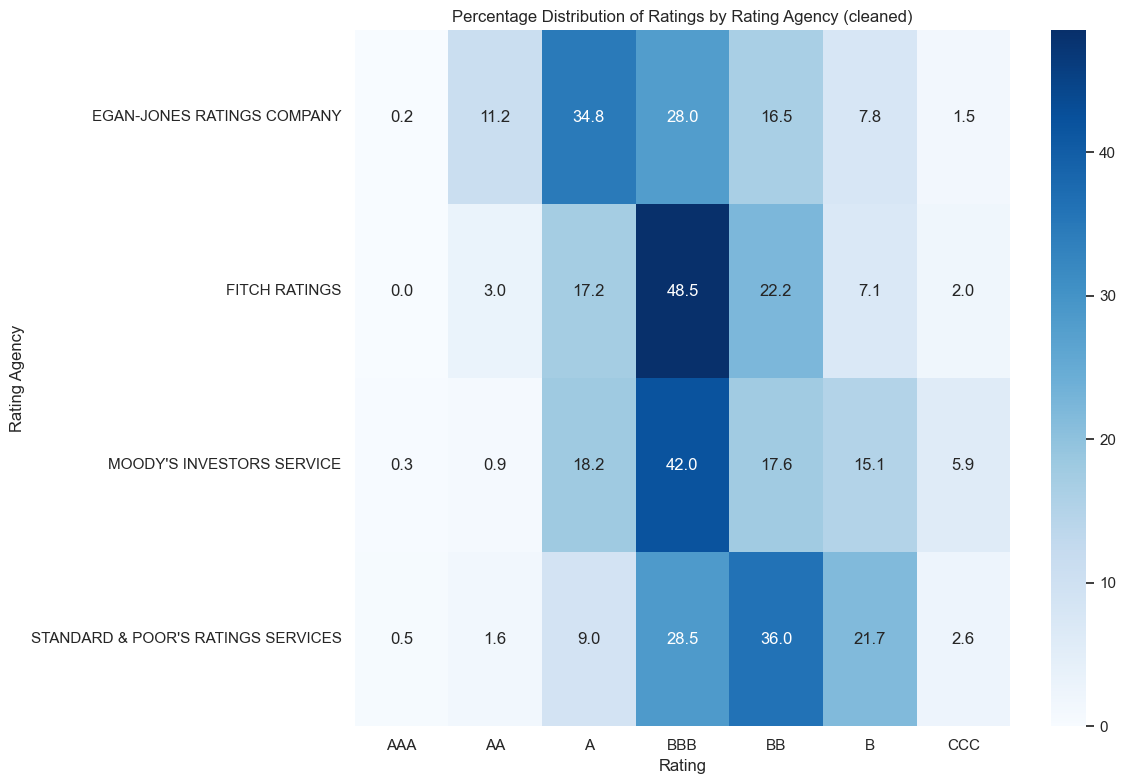

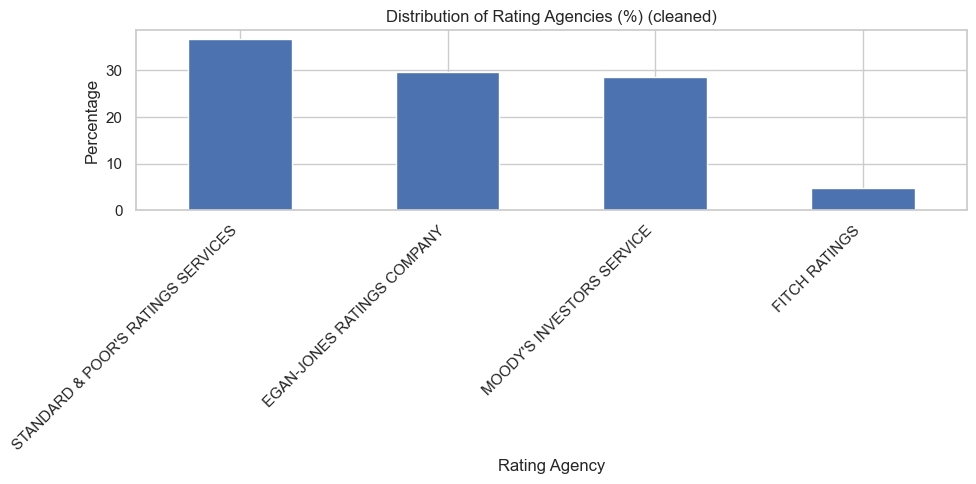

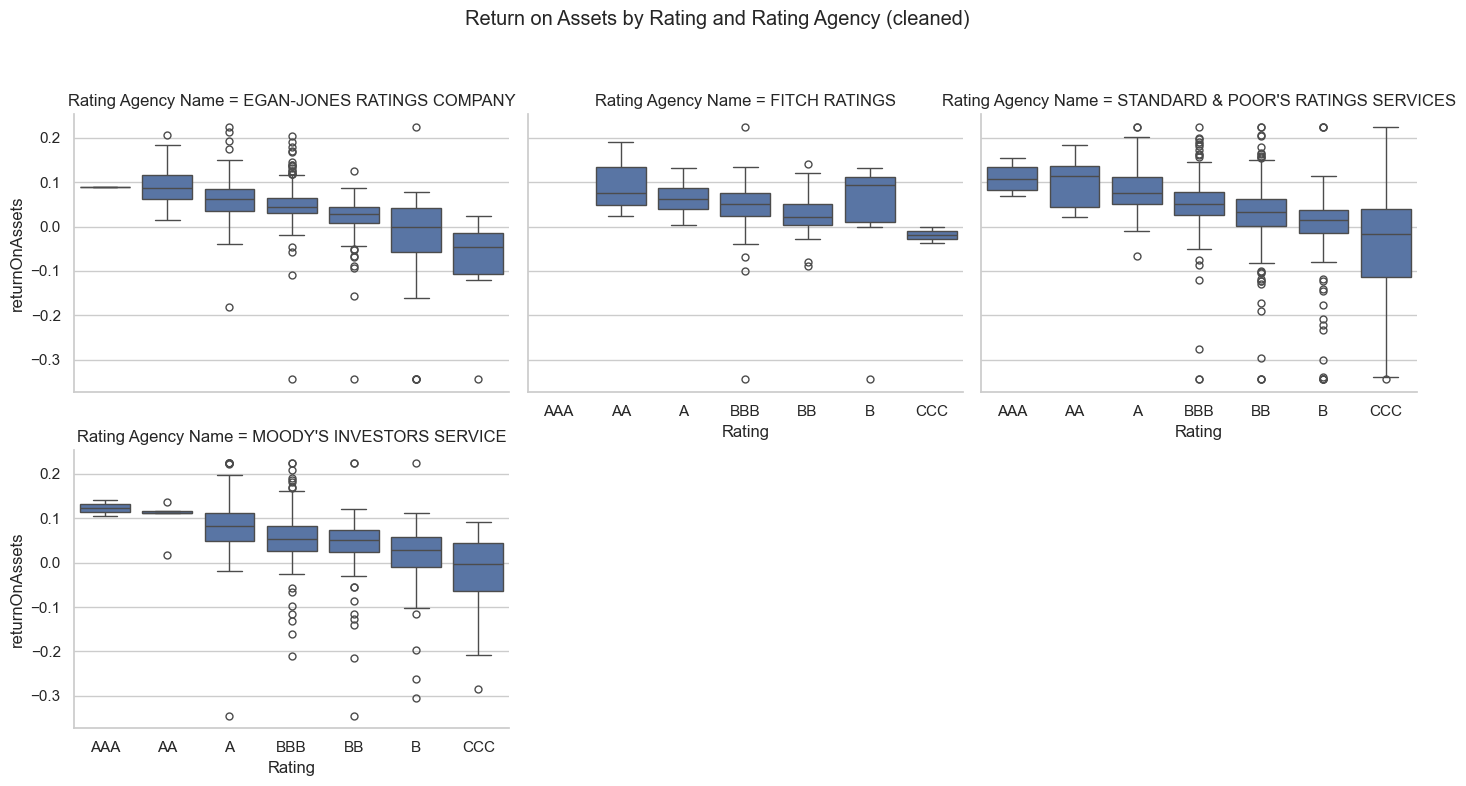

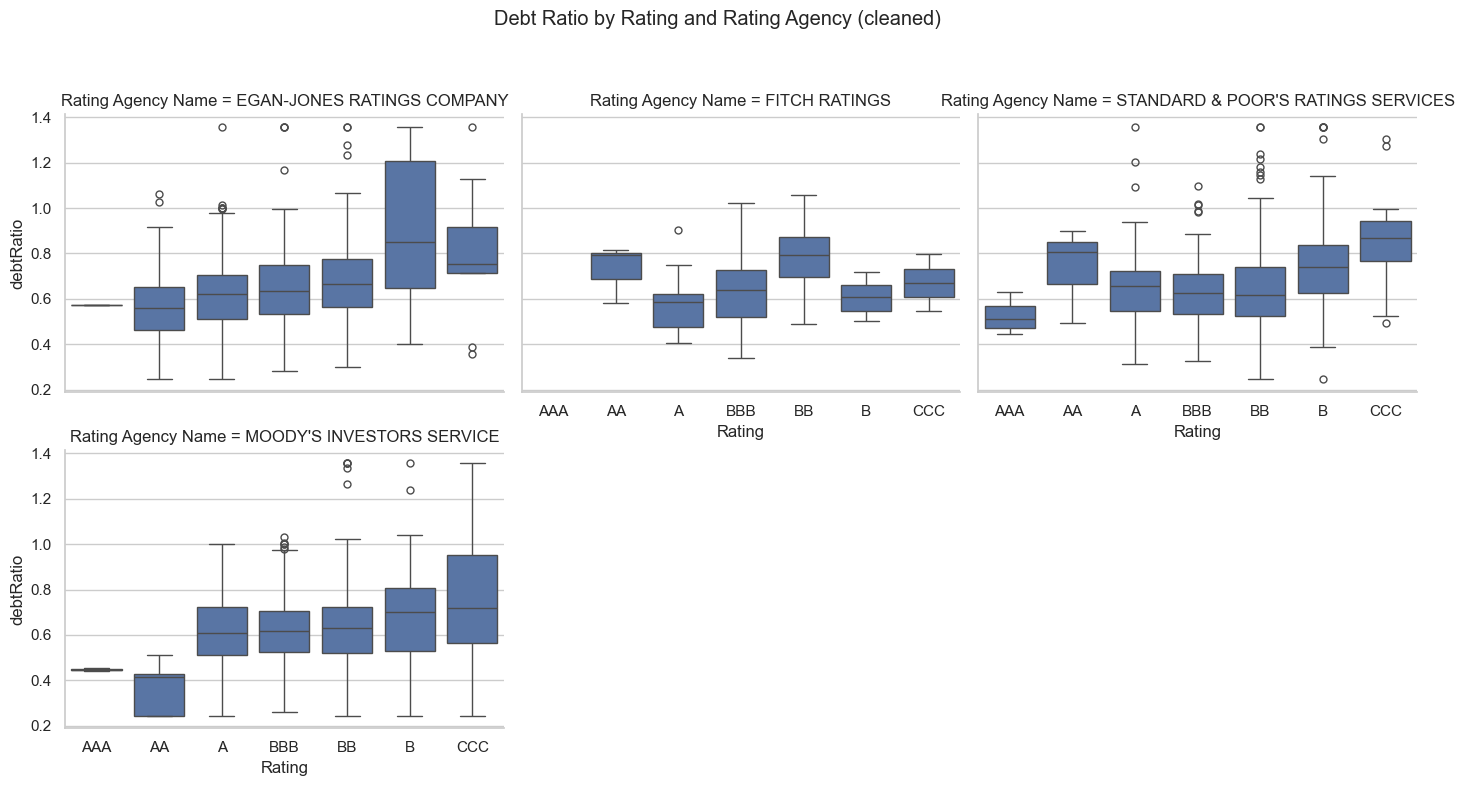

Feature engineering complete!
Total features: 76

New engineered features added:
['roa_debt_ratio', 'debt_current_ratio', 'quick_current_ratio', 'cash_current_ratio', 'gross_operating_margin_diff', 'operating_net_margin_diff', 'roa_x_debt', 'roa_x_current', 'roa_vs_sector_mean', 'debtRatio_vs_sector_mean', 'currentRatio_vs_sector_mean', 'roa_change', 'debtRatio_change', 'currentRatio_change', 'days_since_prev_obs', 'year', 'quarter']

Remaining missing values:
0
Model libraries imported!
Data prepared for modeling!
['Rating', 'Name', 'Symbol', 'Rating Agency Name', 'Date', 'Sector', 'currentRatio', 'quickRatio', 'cashRatio', 'daysOfSalesOutstanding', 'netProfitMargin', 'pretaxProfitMargin', 'grossProfitMargin', 'operatingProfitMargin', 'returnOnAssets', 'returnOnCapitalEmployed', 'returnOnEquity', 'assetTurnover', 'fixedAssetTurnover', 'debtEquityRatio', 'debtRatio', 'effectiveTaxRate', 'freeCashFlowOperatingCashFlowRatio', 'freeCashFlowPerShare', 'cashPerShare', 'companyEquityMultipli

In [14]:
# makes df_processed (and all other variables) available in this notebook.
%run starter_template.ipynb

In [15]:
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    ConfusionMatrixDisplay, roc_curve, auc
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

#CONSTANTS
RANDOM_STATE = 42
RATING_LABELS = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC']

def rating_report(y_true, y_pred):
    lbl = sorted(set(y_true) | set(y_pred))
    names = [RATING_LABELS[l - 1] for l in lbl]
    print(classification_report(y_true, y_pred, labels=lbl, target_names=names))
RATING_SCALE  = {'AAA':1,'AA':2,'A':3,'BBB':4,'BB':5,'B':6,'CCC':7}

print("Imports complete.")

Imports complete.


---
## Data Preparation for Modeling

We split the dataset chronologically:
- Train (70%): earliest observations
- Validation (15%): mid-period observations (used for model selection)
- Test (15%): most recent observations (held out until final evaluation)

The scaler is fitted only on the training set and applied to validation and test.

In [16]:
# Exclude non-feature columns: identifiers, the raw rating string and the target
exclude_cols = ['Rating', 'Rating_encoded', 'Name', 'Symbol', 'Date']
feature_cols = [c for c in df_processed.columns if c not in exclude_cols]
target_col   = 'Rating_encoded'

print(f"Number of features: {len(feature_cols)}")
print(f"Target column: {target_col}")

Number of features: 71
Target column: Rating_encoded


In [38]:
# Sort globally by Date
df_split = df_processed.sort_values('Date').reset_index(drop=True)

n = len(df_split)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)

df_train = df_split.iloc[:n_train].copy()
df_val   = df_split.iloc[n_train : n_train + n_val].copy()
df_test  = df_split.iloc[n_train + n_val :].copy()

X_train_raw = df_train[feature_cols]
y_train     = df_train[target_col]

X_val_raw   = df_val[feature_cols]
y_val       = df_val[target_col]

X_test_raw  = df_test[feature_cols]
y_test      = df_test[target_col]

print(f"Train:{len(df_train):>5} rows ({n_train/n:.0%})")
print(f"Validation:{len(df_val):>5} rows ({n_val/n:.0%})")
print(f"Test:{len(df_test):>5} rows ({(n-n_train-n_val)/n:.0%})")
print()
print("Class distribution in training set:")
dist = y_train.value_counts().sort_index()
for k, v in dist.items():
    print(f"  {k} ({RATING_LABELS[k-1]:>3}): {v:>4} samples  ({v/len(y_train):.1%})")

Train: 1412 rows (70%)
Validation:  302 rows (15%)
Test:  304 rows (15%)

Class distribution in training set:
  1 (AAA):    6 samples  (0.4%)
  2 ( AA):   66 samples  (4.7%)
  3 (  A):  308 samples  (21.8%)
  4 (BBB):  466 samples  (33.0%)
  5 ( BB):  334 samples  (23.7%)
  6 (  B):  192 samples  (13.6%)
  7 (CCC):   40 samples  (2.8%)


In [18]:
# Fit StandardScaler on training data; transform val and test
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (1412, 71)
Validation shape: (302, 71)
Test shape: (304, 71)


---
## 5. Model Development

We train multiple models in order of increasing complexity:

1. Logistic Regression: baseline linear classifier  
2. Random Forest: common decision tree 
3. XGBoost: gradient boosted tree  
4. LightGBM: fast gradient boosting  
5. SMOTE + "best model": handle class imbalance via oversampling on the best model  
6. Hyperparameter tuning: RandomizedSearchCV on best model  

Models are evaluated on the validation set to avoid contaminating the test set.

### 5.1 Baseline: Logistic Regression

Logistic Regression with `class_weight='balanced'` serves as our linear baseline, a practical lower bound on model quality.

In [23]:
#Logistic Regression
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    solver='lbfgs',
    multi_class='auto'
)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_val)

lr_weighted_f1 = f1_score(y_val, y_pred_lr, average='weighted')
lr_macro_f1 = f1_score(y_val, y_pred_lr, average='macro')
lr_accuracy = accuracy_score(y_val, y_pred_lr)

print("Logistic Regression — Validation")
rating_report(y_val, y_pred_lr)
print(f"Weighted F1: {lr_weighted_f1:.4f}")
print(f"Macro F1: {lr_macro_f1:.4f}")
print(f"Accuracy: {lr_accuracy:.4f}")

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

### 5.2 Random Forest

Random Forest handles non-linear relationships well and is robust to outliers. `class_weight='balanced'` adjusts for the imbalanced rating distribution.

In [39]:
# Random Forest 
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_val)

rf_weighted_f1 = f1_score(y_val, y_pred_rf, average='weighted')
rf_macro_f1 = f1_score(y_val, y_pred_rf, average='macro')
rf_accuracy = accuracy_score(y_val, y_pred_rf)

print("Random Forest — Validation")
rating_report(y_val, y_pred_rf)
print(f"Weighted F1: {rf_weighted_f1:.4f}")
print(f"Macro F1: {rf_macro_f1:.4f}")
print(f"Accuracy: {rf_accuracy:.4f}")

Random Forest — Validation
              precision    recall  f1-score   support

          AA       1.00      0.35      0.52        17
           A       0.66      0.68      0.67        63
         BBB       0.55      0.72      0.62        94
          BB       0.46      0.51      0.49        68
           B       0.73      0.43      0.54        51
         CCC       0.00      0.00      0.00         9

    accuracy                           0.58       302
   macro avg       0.57      0.45      0.47       302
weighted avg       0.59      0.58      0.56       302

Weighted F1: 0.5649
Macro F1: 0.4745
Accuracy: 0.5762


### 5.3 XGBoost

XGBoost is a gradient boosted.
It requires 0-indexed labels, so we shift `Rating_encoded` (1–7) to (0–6) for training
and shift predictions back when evaluating.

In [40]:
# XGBoost 
# shift 1-7 → 0-6
y_train_xgb = y_train - 1   
y_val_xgb = y_val - 1

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train_xgb)
y_pred_xgb_raw = xgb_model.predict(X_val) 
# shift back to 1-7 for evaluation      
y_pred_xgb = y_pred_xgb_raw + 1             

xgb_weighted_f1 = f1_score(y_val, y_pred_xgb, average='weighted')
xgb_macro_f1 = f1_score(y_val, y_pred_xgb, average='macro')
xgb_accuracy = accuracy_score(y_val, y_pred_xgb)

print("XGBoost — Validation")
rating_report(y_val, y_pred_xgb)
print(f"Weighted F1: {xgb_weighted_f1:.4f}")
print(f"Macro F1: {xgb_macro_f1:.4f}")
print(f"Accuracy: {xgb_accuracy:.4f}")

XGBoost — Validation
              precision    recall  f1-score   support

          AA       0.80      0.47      0.59        17
           A       0.65      0.68      0.67        63
         BBB       0.56      0.65      0.60        94
          BB       0.51      0.56      0.54        68
           B       0.62      0.49      0.55        51
         CCC       0.33      0.11      0.17         9

    accuracy                           0.58       302
   macro avg       0.58      0.49      0.52       302
weighted avg       0.59      0.58      0.58       302

Weighted F1: 0.5778
Macro F1: 0.5186
Accuracy: 0.5828


### 5.4 LightGBM

LightGBM is a fast gradient boosting framework using histogram-based learning.

In [41]:
# LightGBM
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_val)

lgbm_weighted_f1 = f1_score(y_val, y_pred_lgbm, average='weighted')
lgbm_macro_f1 = f1_score(y_val, y_pred_lgbm, average='macro')
lgbm_accuracy = accuracy_score(y_val, y_pred_lgbm)

print("LightGBM — Validation")
rating_report(y_val, y_pred_lgbm)
print(f"Weighted F1: {lgbm_weighted_f1:.4f}")
print(f"Macro F1: {lgbm_macro_f1:.4f}")
print(f"Accuracy: {lgbm_accuracy:.4f}")

LightGBM — Validation
              precision    recall  f1-score   support

          AA       0.80      0.47      0.59        17
           A       0.69      0.75      0.72        63
         BBB       0.59      0.67      0.63        94
          BB       0.53      0.59      0.56        68
           B       0.61      0.45      0.52        51
         CCC       0.25      0.11      0.15         9

    accuracy                           0.60       302
   macro avg       0.58      0.51      0.53       302
weighted avg       0.60      0.60      0.60       302

Weighted F1: 0.5961
Macro F1: 0.5277
Accuracy: 0.6026


### 5.5 Class Imbalance: SMOTE Oversampling

The dataset is highly imbalanced: BBB (class 4) dominates while AAA (class 1) has very few samples.
SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic minority-class samples
to balance the training distribution.

We apply SMOTE to the training set and refit the best-performing model.

In [42]:
# SMOTE Oversampling
# k_neighbors=2 is used because very few training samples may be present in some credit categories.
# Evaluation is always on the original validation set.
smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=2)

try:
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"SMOTE applied: {len(y_train)} → {len(y_train_res)} training samples")
    print("Resampled class distribution:")
    res_dist = pd.Series(y_train_res).value_counts().sort_index()
    for k, v in res_dist.items():
        print(f"{k} ({RATING_LABELS[k-1]:>3}): {v:>4} samples")
except Exception as e:
    print(f"SMOTE failed ({e}).")
    X_train_res, y_train_res = X_train, y_train

# Refit model on resampled data
lgbm_smote = LGBMClassifier(
    n_estimators=200,
    max_depth=10,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)
lgbm_smote.fit(X_train_res, y_train_res)
y_pred_lgbm_smote = lgbm_smote.predict(X_val)

lgbm_smote_weighted_f1 = f1_score(y_val, y_pred_lgbm_smote, average='weighted')
lgbm_smote_macro_f1 = f1_score(y_val, y_pred_lgbm_smote, average='macro')
lgbm_smote_accuracy = accuracy_score(y_val, y_pred_lgbm_smote)

print("LightGBM + SMOTE — Validation")
rating_report(y_val, y_pred_lgbm_smote)
print(f"Weighted F1: {lgbm_smote_weighted_f1:.4f}")
print(f"Macro F1: {lgbm_smote_macro_f1:.4f}")
print(f"Accuracy: {lgbm_smote_accuracy:.4f}")

SMOTE applied: 1412 → 3262 training samples
Resampled class distribution:
1 (AAA):  466 samples
2 ( AA):  466 samples
3 (  A):  466 samples
4 (BBB):  466 samples
5 ( BB):  466 samples
6 (  B):  466 samples
7 (CCC):  466 samples
LightGBM + SMOTE — Validation
              precision    recall  f1-score   support

          AA       0.77      0.59      0.67        17
           A       0.66      0.63      0.65        63
         BBB       0.56      0.64      0.60        94
          BB       0.49      0.59      0.54        68
           B       0.66      0.49      0.56        51
         CCC       0.00      0.00      0.00         9

    accuracy                           0.58       302
   macro avg       0.52      0.49      0.50       302
weighted avg       0.58      0.58      0.57       302

Weighted F1: 0.5737
Macro F1: 0.5013
Accuracy: 0.5795


### 5.6 Hyperparameter Tuning — LightGBM

We apply RandomizedSearchCV to find the optimal hyperparameters for LightGBM, testing 50 random combinations with 5-fold cross-validation, optimizing for weighted F1-score.

In [43]:
# 5.6 Hyperparameter Tuning — LightGBM
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':    [200, 400, 600, 800],
    'max_depth':       [5, 8, 10, 15, -1],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'num_leaves':      [31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha':       [0, 0.1, 0.5],
    'reg_lambda':      [0, 0.1, 1.0],
}

lgbm_base = LGBMClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

search = RandomizedSearchCV(
    lgbm_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_weighted',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print(f"Best CV weighted F1: {search.best_score_:.4f}")

y_pred_tuned = search.best_estimator_.predict(X_val)
tuned_weighted_f1 = f1_score(y_val, y_pred_tuned, average='weighted')
tuned_macro_f1    = f1_score(y_val, y_pred_tuned, average='macro')
tuned_accuracy    = accuracy_score(y_val, y_pred_tuned)

print("\nLightGBM Tuned — Validation")
rating_report(y_val, y_pred_tuned)
print(f"Weighted F1: {tuned_weighted_f1:.4f}")
print(f"Macro F1:    {tuned_macro_f1:.4f}")
print(f"Accuracy:    {tuned_accuracy:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 63, 'n_estimators': 400, 'min_child_samples': 20, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Best CV weighted F1: 0.5610

LightGBM Tuned — Validation
              precision    recall  f1-score   support

          AA       0.90      0.53      0.67        17
           A       0.70      0.67      0.68        63
         BBB       0.58      0.69      0.63        94
          BB       0.51      0.56      0.53        68
           B       0.66      0.53      0.59        51
         CCC       0.25      0.11      0.15         9

    accuracy                           0.60       302
   macro avg       0.60      0.51      0.54       302
weighted avg       0.61      0.60      0.60       302

Weighted F1: 0.5998
Macro F1:    0.5422
Accuracy:    0.6026


### 5.7 SMOTE + Hyperparameter Tuning

Since SMOTE balances the training data by generating synthetic samples for minority 
classes, we test whether combining it with hyperparameter tuning improves performance 
over tuning alone. When using SMOTE, we remove class_weight='balanced' to avoid 
double-correcting for class imbalance — SMOTE already handles this by equalizing 
the class distribution.


In [26]:
# 5.7 SMOTE + Hyperparameter Tuning — LightGBM

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':    [200, 400, 600, 800],
    'max_depth':       [5, 8, 10, 15, -1],
    'learning_rate':   [0.01, 0.05, 0.1, 0.2],
    'num_leaves':      [31, 63, 127],
    'min_child_samples': [10, 20, 50],
    'subsample':       [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'reg_alpha':       [0, 0.1, 0.5],
    'reg_lambda':      [0, 0.1, 1.0],
}

lgbm_smote_base = LGBMClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
    # niente class_weight: SMOTE ha già bilanciato
)

search_smote = RandomizedSearchCV(
    lgbm_smote_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_weighted',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Allena sul dataset bilanciato da SMOTE
search_smote.fit(X_train_res, y_train_res)

print("Best params:", search_smote.best_params_)
print(f"Best CV weighted F1: {search_smote.best_score_:.4f}")

# Valuta sempre sul validation set originale
y_pred_smote_tuned = search_smote.best_estimator_.predict(X_val)
smote_tuned_f1 = f1_score(y_val, y_pred_smote_tuned, average='weighted')
smote_tuned_macro = f1_score(y_val, y_pred_smote_tuned, average='macro')
smote_tuned_acc = accuracy_score(y_val, y_pred_smote_tuned)

print("\nLightGBM SMOTE + Tuned — Validation")
rating_report(y_val, y_pred_smote_tuned)
print(f"Weighted F1: {smote_tuned_f1:.4f}")
print(f"Macro F1:    {smote_tuned_macro:.4f}")
print(f"Accuracy:    {smote_tuned_acc:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 50, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
Best CV weighted F1: 0.7746

LightGBM SMOTE + Tuned — Validation
              precision    recall  f1-score   support

          AA       0.69      0.53      0.60        17
           A       0.66      0.60      0.63        63
         BBB       0.54      0.64      0.59        94
          BB       0.51      0.56      0.53        68
           B       0.60      0.49      0.54        51
         CCC       0.00      0.00      0.00         9

    accuracy                           0.56       302
   macro avg       0.50      0.47      0.48       302
weighted avg       0.56      0.56      0.56       302

Weighted F1: 0.5575
Macro F1:    0.4804
Accuracy:    0.5629


### 5.8 HistGradientBoostingClassifier

Scikit-learn's native histogram-based gradient boosting (HistGBM) uses a different
algorithmic path than LightGBM: native missing-value handling and monotonic constraints
are built-in. It does not have a `class_weight` constructor argument for all sklearn
versions, so we pass per-sample weights via `compute_sample_weight` in `.fit()`.
This gives the model equivalent information about class imbalance while remaining
fully compatible with the sklearn API.

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

hgbm = HistGradientBoostingClassifier(
    max_iter=500,
    max_depth=8,
    learning_rate=0.05,
    max_leaf_nodes=31,
    min_samples_leaf=20,
    l2_regularization=0.1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
    verbose=0
)
hgbm.fit(X_train, y_train, sample_weight=sample_weights_train)

y_pred_hgbm = hgbm.predict(X_val)

hgbm_weighted_f1 = f1_score(y_val, y_pred_hgbm, average='weighted')
hgbm_macro_f1    = f1_score(y_val, y_pred_hgbm, average='macro')
hgbm_accuracy    = accuracy_score(y_val, y_pred_hgbm)

print(f'HistGBM stopped at iteration: {hgbm.n_iter_}')
print('\nHistGradientBoostingClassifier â Validation')
rating_report(y_val, y_pred_hgbm)
print(f'Weighted F1 : {hgbm_weighted_f1:.4f}')
print(f'Macro F1    : {hgbm_macro_f1:.4f}')
print(f'Accuracy    : {hgbm_accuracy:.4f}')


### 5.9 Stacking Ensemble

Stacking (stacked generalisation) trains a meta-learner on the out-of-fold predictions
of diverse base models. Each base model's predicted class probabilities become features
for the meta-learner, which learns to combine their strengths.

Base estimators chosen for diversity:
- Random Forest: bagging-based, captures feature interactions through many independent trees
- HistGradientBoostingClassifier: boosting-based, handles the fitted HistGBM above
- LightGBM (fresh instance): gradient boosting with leaf-wise growth

Meta-learner: LightGBM â powerful enough to learn non-linear combinations of base
model outputs while staying fast.

All models accept labels 1â7 directly. XGBoost is excluded because it requires
0-indexed labels and would need a label-shift wrapper, adding complexity.


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import StratifiedKFold

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

base_estimators = [
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=15,
        class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=1
    )),
    ('hgbm_stack', HistGradientBoostingClassifier(
        max_iter=300, max_depth=6, learning_rate=0.08,
        max_leaf_nodes=31, min_samples_leaf=15,
        l2_regularization=0.1,
        early_stopping=False,
        random_state=RANDOM_STATE
    )),
    ('lgbm_stack', LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.08,
        num_leaves=40, min_child_samples=20,
        class_weight='balanced', subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE, n_jobs=1, verbose=-1
    )),
]

meta_learner = LGBMClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    num_leaves=20, min_child_samples=10,
    class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=1, verbose=-1
)

stack_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=cv5,
    stack_method='predict_proba',
    n_jobs=1,
    passthrough=False
)
stack_clf.fit(X_train, y_train)

y_pred_stack = stack_clf.predict(X_val)

stack_weighted_f1 = f1_score(y_val, y_pred_stack, average='weighted')
stack_macro_f1    = f1_score(y_val, y_pred_stack, average='macro')
stack_accuracy    = accuracy_score(y_val, y_pred_stack)

print('Stacking Ensemble — Validation')
rating_report(y_val, y_pred_stack)
print(f'Weighted F1 : {stack_weighted_f1:.4f}')
print(f'Macro F1    : {stack_macro_f1:.4f}')
print(f'Accuracy    : {stack_accuracy:.4f}')


---
## 6. Model Evaluation

We compare all trained models on the validation set, display the confusion matrix for
the best model, and report final performance on the held-out test set.

The test set has never been used for any model selection or tuning decision â this is
the first and only time it is evaluated.


In [ ]:
results_table = pd.DataFrame({
    'Model': [
        'Logistic Regression', 'Random Forest', 'XGBoost',
        'LightGBM (plain)', 'LightGBM + SMOTE',
        'Tuned LightGBM', 'SMOTE + Tuned LightGBM',
        'HistGradientBoosting', 'Stacking Ensemble',
    ],
    'Weighted F1': [
        lr_weighted_f1, rf_weighted_f1, xgb_weighted_f1,
        lgbm_weighted_f1, lgbm_smote_weighted_f1,
        tuned_weighted_f1, smote_tuned_f1,
        hgbm_weighted_f1, stack_weighted_f1,
    ],
    'Macro F1': [
        lr_macro_f1, rf_macro_f1, xgb_macro_f1,
        lgbm_macro_f1, lgbm_smote_macro_f1,
        tuned_macro_f1, smote_tuned_macro,
        hgbm_macro_f1, stack_macro_f1,
    ],
    'Accuracy': [
        lr_accuracy, rf_accuracy, xgb_accuracy,
        lgbm_accuracy, lgbm_smote_accuracy,
        tuned_accuracy, smote_tuned_acc,
        hgbm_accuracy, stack_accuracy,
    ],
})

results_table = results_table.sort_values('Weighted F1', ascending=False).reset_index(drop=True)
results_table[['Weighted F1', 'Macro F1', 'Accuracy']] = \
    results_table[['Weighted F1', 'Macro F1', 'Accuracy']].round(4)

print('=' * 65)
print(f'{"Model":<25} {"Weighted F1":>12} {"Macro F1":>10} {"Accuracy":>10}')
print('=' * 65)
for _, row in results_table.iterrows():
    marker = ' <-- BEST' if row['Weighted F1'] == results_table['Weighted F1'].max() else ''
    print(f"{row['Model']:<25} {row['Weighted F1']:>12.4f} {row['Macro F1']:>10.4f} "
          f"{row['Accuracy']:>10.4f}{marker}")
print('=' * 65)
print(f"\nTarget: Weighted F1 > 0.65")
print(f"Best val weighted F1: {results_table['Weighted F1'].max():.4f}")


In [ ]:
import matplotlib.pyplot as plt

best_model_name = results_table.iloc[0]['Model']
print(f'Best model: {best_model_name}  (val weighted F1 = {results_table.iloc[0]["Weighted F1"]:.4f})\n')

model_registry = {
    'Logistic Regression':    (lr_model,                      y_pred_lr),
    'Random Forest':           (rf_model,                      y_pred_rf),
    'XGBoost':                 (xgb_model,                     y_pred_xgb),
    'LightGBM (plain)':        (lgbm_model,                    y_pred_lgbm),
    'LightGBM + SMOTE':        (lgbm_smote,                    y_pred_lgbm_smote),
    'Tuned LightGBM':          (search.best_estimator_,        y_pred_tuned),
    'SMOTE + Tuned LightGBM':  (search_smote.best_estimator_,  y_pred_smote_tuned),
    'HistGradientBoosting':    (hgbm,                          y_pred_hgbm),
    'Stacking Ensemble':       (stack_clf,                     y_pred_stack),
}

best_model_obj, best_y_pred_val = model_registry[best_model_name]

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val, best_y_pred_val,
    display_labels=RATING_LABELS,
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name}\n(Validation Set)', fontsize=13)
plt.tight_layout()
plt.show()

print('\n' + '=' * 60)
print('FINAL TEST SET EVALUATION')
print('=' * 60)
print(f'Model: {best_model_name}\n')

if best_model_name == 'XGBoost':
    y_pred_test = best_model_obj.predict(X_test) + 1
else:
    y_pred_test = best_model_obj.predict(X_test)

test_weighted_f1 = f1_score(y_test, y_pred_test, average='weighted')
test_macro_f1    = f1_score(y_test, y_pred_test, average='macro')
test_accuracy    = accuracy_score(y_test, y_pred_test)

rating_report(y_test, y_pred_test)
print(f'Weighted F1 : {test_weighted_f1:.4f}')
print(f'Macro F1    : {test_macro_f1:.4f}')
print(f'Accuracy    : {test_accuracy:.4f}')
